In [18]:
import bigframes  # Adds a .bigquery accessor to DataFrame and Series
import pandas as pd

lightning = pd.read_parquet("lightning.parquet")
dates = pd.date_range("1990-01-01", "2025-12-31", tz="UTC")
lightning_all = dates.to_frame().join(lightning).drop(columns=[0]).fillna(0)
lightning_all

,number_of_strikes
1990-01-01 00:00:00+00:00,0
1990-01-02 00:00:00+00:00,0
1990-01-03 00:00:00+00:00,0
1990-01-04 00:00:00+00:00,0
1990-01-05 00:00:00+00:00,0
...,...
2025-12-27 00:00:00+00:00,0
2025-12-28 00:00:00+00:00,0
2025-12-29 00:00:00+00:00,0
2025-12-30 00:00:00+00:00,0


<Axes: >

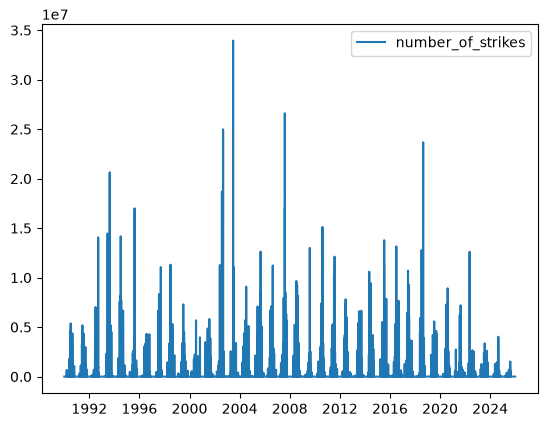

In [19]:
import seaborn

seaborn.lineplot(lightning_all)

In [8]:
lightning_all

,number_of_strikes
date,
1990-01-01 00:00:00+00:00,0
1990-01-02 00:00:00+00:00,0
1990-01-03 00:00:00+00:00,0
1990-01-04 00:00:00+00:00,0
1990-01-05 00:00:00+00:00,0
...,...
2025-12-27 00:00:00+00:00,0
2025-12-28 00:00:00+00:00,0
2025-12-29 00:00:00+00:00,0


In [9]:
forecast = lightning_all.reset_index(drop=False).bigquery.ai.forecast(data_col="number_of_strikes", timestamp_col="date", horizon=365)

/Users/swast/src/github.com/tswast/code-snippets/2026/scipy-lightning-talk/.venv/lib/python3.14/site-packages/bigframes/core/global_session.py:113: DefaultLocationWarning: No explicit location is set, so using location US for the session.
  _global_session = bigframes.session.connect(


In [10]:
forecast_indexed = forecast.sort_values("forecast_timestamp").set_index("forecast_timestamp")

In [11]:
forecast_indexed

,forecast_value,confidence_level,prediction_interval_lower_bound,prediction_interval_upper_bound,ai_forecast_status
forecast_timestamp,,,,,
2026-01-01 00:00:00+00:00,6060.625,0.95,-56725.879543,-7239.165199,
2026-01-02 00:00:00+00:00,13097.84375,0.95,-49825.873584,-11931.386324,
2026-01-03 00:00:00+00:00,-34465.859375,0.95,-68217.840257,2047.921304,
2026-01-04 00:00:00+00:00,-24413.78125,0.95,-94120.558786,-38065.3735,
2026-01-05 00:00:00+00:00,-12948.0,0.95,-63249.269826,-4056.80426,
...,...,...,...,...,...
2026-12-27 00:00:00+00:00,-1930.023682,0.95,-123670.989278,147365.348243,
2026-12-28 00:00:00+00:00,2695.100586,0.95,-119077.982389,152339.009231,
2026-12-29 00:00:00+00:00,-1651.451416,0.95,-123636.669868,148066.721489,


<Axes: xlabel='forecast_timestamp', ylabel='forecast_value'>

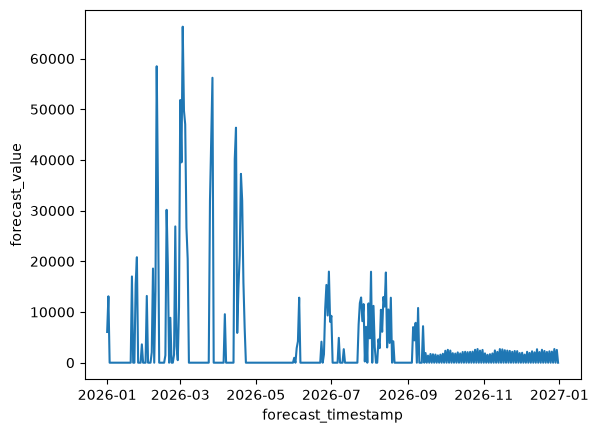

In [12]:
forecast_indexed.index = forecast_indexed.index.astype("datetime64[ns, UTC]")
seaborn.lineplot(forecast_indexed["forecast_value"].clip(0))

In [14]:
forecast_subset = forecast_indexed[
    ["forecast_value", "prediction_interval_lower_bound", "prediction_interval_upper_bound"]
].clip(0).reset_index(drop=False)
forecast_subset['forecast_timestamp'] = forecast_subset['forecast_timestamp'].astype("datetime64[ns, UTC]")
forecast_melt = pd.melt(forecast_subset, ["forecast_timestamp"])
forecast_melt

,forecast_timestamp,variable,value
0,2026-01-01 00:00:00+00:00,forecast_value,6060.625
1,2026-01-02 00:00:00+00:00,forecast_value,13097.84375
2,2026-01-03 00:00:00+00:00,forecast_value,0.0
3,2026-01-04 00:00:00+00:00,forecast_value,0.0
4,2026-01-05 00:00:00+00:00,forecast_value,0.0
...,...,...,...
1090,2026-12-27 00:00:00+00:00,prediction_interval_upper_bound,147365.348243
1091,2026-12-28 00:00:00+00:00,prediction_interval_upper_bound,152339.009231
1092,2026-12-29 00:00:00+00:00,prediction_interval_upper_bound,148066.721489
1093,2026-12-30 00:00:00+00:00,prediction_interval_upper_bound,152065.105687


<Axes: xlabel='forecast_timestamp', ylabel='value'>

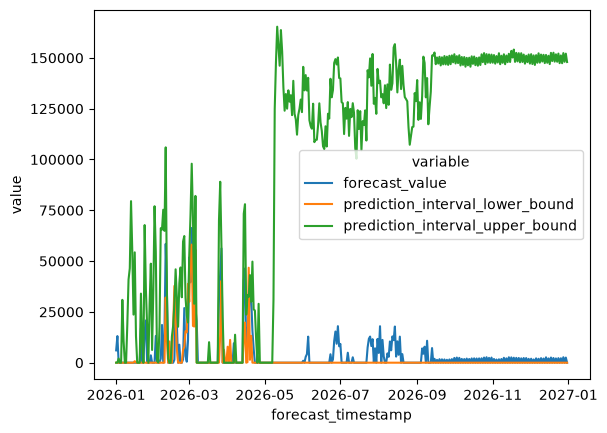

In [15]:
seaborn.lineplot(forecast_melt, x="forecast_timestamp", y="value", hue="variable")

<Axes: xlabel='monthday'>

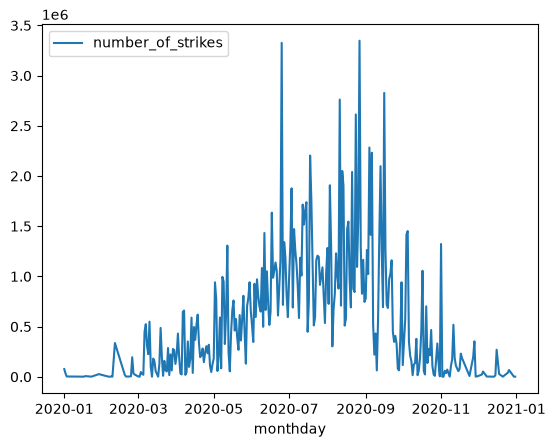

In [31]:
lightning_month = lightning.index.month
lightning_day = lightning.index.day
lightning_monthday = pd.to_datetime(pd.DataFrame({"year": [2020]*len(lightning.index), "month": lightning_month, "day": lightning_day}, index=lightning.index))
lightning_averages = lightning.assign(monthday=lightning_monthday).groupby("monthday").agg({"number_of_strikes": "mean"})
seaborn.lineplot(lightning_averages)